In [25]:
"""
Task 0 helper for the Applied Trading Strategies backtesting project.

Purpose
-------
1. Read the commodities workbook.
2. Clean the commodity rebased-index table and align it with data/raw/assets.csv.
3. Convert excess return indices into daily simple returns.
4. Build an equally weighted commodity market factor to use as the benchmark.
5. Save clean outputs for later strategy/model backtests.

Input files expected:
    source/Commodities Data thru 18May26.xlsx with sheet:
    - Rebased
    data/raw/assets.csv for commodity names and sectors

The factor is calculated from daily returns, not from index levels directly.
Missing commodity returns are not filled with zero. The script outputs two factor
versions:
    - MKT_EQ_WEIGHT_AVAILABLE: average of commodities with available return on that date
    - MKT_EQ_WEIGHT_FULL_UNIVERSE: average only when all 23 commodities have returns

For later model benchmarking, use one consistently across the report. The default
benchmark returned by `build_task0_dataset` is MKT_EQ_WEIGHT_AVAILABLE because it
keeps the maximum history while making the active universe count explicit.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd

def find_project_root() -> Path:
    """Find the repository root whether the notebook runs from root or tasks/task_3."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "source").exists() and (base / "tasks" / "task_3").exists():
            return base
    return Path.cwd()


PROJECT_ROOT = find_project_root()
TASK3_OUTPUT_BASE = PROJECT_ROOT / "tasks" / "task_3" / "outputs"


# -----------------------------------------------------------------------------
# User-editable settings
# -----------------------------------------------------------------------------
COMMODITIES_FILE = Path("source/Commodities Data thru 18May26.xlsx")
ASSETS_FILE = Path("data/raw/assets.csv")
RETURN_INDICES_SHEET = "Rebased"
DATE_COL = "Dates"
TRAIN_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")
TRADING_DAYS_PER_YEAR = 252


@dataclass
class Task0Data:
    """Container returned by the Task 0 data-building function."""

    index_levels: pd.DataFrame
    returns: pd.DataFrame
    assets: pd.DataFrame
    market_factor: pd.DataFrame
    summary_stats: pd.DataFrame
    corr_matrix: pd.DataFrame


# -----------------------------------------------------------------------------
# Cleaning helpers
# -----------------------------------------------------------------------------
def _normalise_text(x: object) -> str:
    """Standardise strings for reliable matching between source files."""
    return " ".join(str(x).strip().upper().split())


def _match_return_columns_to_assets(
    return_columns: Iterable[str], assets: pd.DataFrame
) -> Dict[str, str]:
    """Match source workbook columns to clean commodity names using assets.csv."""
    colname_map = dict(zip(assets["ColName"].map(_normalise_text), assets["Commodity"]))
    asset_names = [str(a).strip() for a in assets["Commodity"]]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(_normalise_text(s)), reverse=True)

    mapping: Dict[str, str] = {}
    unmatched = []

    for raw_col in return_columns:
        raw_norm = _normalise_text(raw_col)
        match = colname_map.get(raw_norm)
        if match is None:
            for asset in asset_names_sorted:
                if raw_norm.startswith(_normalise_text(asset)):
                    match = asset
                    break

        if match is None:
            unmatched.append(raw_col)
        else:
            mapping[raw_col] = match

    if unmatched:
        raise ValueError(
            "Could not match these source commodity columns to assets.csv: "
            + ", ".join(map(str, unmatched))
        )

    clean_names = list(mapping.values())
    if len(clean_names) != len(set(clean_names)):
        duplicates = pd.Series(clean_names).value_counts()
        duplicates = duplicates[duplicates > 1].index.tolist()
        raise ValueError(f"Duplicate asset-name mapping detected: {duplicates}")

    return mapping


def _find_existing_path(path: Path | str) -> Path:
    """Find repo inputs whether the notebook is run from root or a subfolder."""
    path = Path(path)
    candidates = [path]
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([base / path, base / path.name])
    candidates.extend([Path("/mnt/data") / path, Path("/mnt/data") / path.name])

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {path}. Tried: {unique_candidates}")


def _load_asset_metadata(assets_file: Path | str = ASSETS_FILE) -> pd.DataFrame:
    assets_path = _find_existing_path(assets_file)
    assets = pd.read_csv(assets_path)
    required_asset_cols = {"Commodity", "Sector", "ColName"}
    missing_asset_cols = required_asset_cols - set(assets.columns)
    if missing_asset_cols:
        raise ValueError(f"assets.csv is missing columns: {sorted(missing_asset_cols)}")
    assets = assets.copy()
    for col in ["Commodity", "Sector", "ColName"]:
        assets[col] = assets[col].astype(str).str.strip()
    return assets


def load_commodities_workbook(
    file_path: Path | str = COMMODITIES_FILE,
    return_sheet: str = RETURN_INDICES_SHEET,
    assets_file: Path | str = ASSETS_FILE,
    date_col: str = DATE_COL,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load source rebased levels and the asset sector map."""
    file_path = _find_existing_path(file_path)
    raw_indices = pd.read_excel(file_path, sheet_name=return_sheet)
    assets = _load_asset_metadata(assets_file)

    if date_col not in raw_indices.columns:
        raise ValueError(f"{return_sheet} sheet must contain a '{date_col}' column.")

    raw_indices = raw_indices.copy()
    raw_indices[date_col] = pd.to_datetime(raw_indices[date_col])
    raw_indices = raw_indices.dropna(subset=[date_col]).sort_values(date_col)
    raw_indices = raw_indices.drop_duplicates(subset=[date_col], keep="last")
    raw_indices = raw_indices.set_index(date_col)
    raw_indices = raw_indices.apply(pd.to_numeric, errors="coerce")

    col_map = _match_return_columns_to_assets(raw_indices.columns, assets)
    index_levels = raw_indices.rename(columns=col_map)
    ordered_assets = assets["Commodity"].tolist()
    index_levels = index_levels[ordered_assets]

    return index_levels, assets


# -----------------------------------------------------------------------------
# Core calculations
# -----------------------------------------------------------------------------
def compute_daily_returns(index_levels: pd.DataFrame) -> pd.DataFrame:
    """
    Convert excess return indices into daily simple returns.

    Important: fill_method=None prevents pandas from forward-filling missing index
    levels before calculating returns. This avoids accidentally creating artificial
    zero returns when an asset has not started trading in the dataset.
    """
    returns = index_levels.pct_change(fill_method=None)
    returns = returns.replace([np.inf, -np.inf], np.nan)
    return returns


def build_market_factor(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Construct the equally weighted commodity market factor.

    MKT_EQ_WEIGHT_AVAILABLE averages across non-missing commodity returns on each
    date. MKT_EQ_WEIGHT_FULL_UNIVERSE only reports a value when every commodity has
    a valid return on the same date.
    """
    n_assets = returns.shape[1]
    active_assets = returns.notna().sum(axis=1)

    factor_available = returns.mean(axis=1, skipna=True)
    factor_available = factor_available.where(active_assets > 0)

    factor_full = returns.where(active_assets.eq(n_assets)).mean(axis=1, skipna=True)
    factor_full = factor_full.where(active_assets.eq(n_assets))

    out = pd.DataFrame(
        {
            "MKT_EQ_WEIGHT_AVAILABLE": factor_available,
            "MKT_EQ_WEIGHT_FULL_UNIVERSE": factor_full,
            "ACTIVE_ASSETS": active_assets,
            "TOTAL_ASSETS": n_assets,
        },
        index=returns.index,
    )

    # Cumulative benchmark indices, starting at 100. These are for plotting only.
    for col in ["MKT_EQ_WEIGHT_AVAILABLE", "MKT_EQ_WEIGHT_FULL_UNIVERSE"]:
        idx_col = col.replace("MKT_EQ_WEIGHT", "MKT_INDEX")
        valid = out[col].dropna()
        index_series = pd.Series(np.nan, index=out.index, dtype=float)
        if not valid.empty:
            index_series.loc[valid.index] = 100.0 * (1.0 + valid).cumprod()
        out[idx_col] = index_series

    out["SAMPLE"] = np.where(out.index <= TRAIN_END, "Train", "Test")
    return out


def calculate_summary_stats(returns: pd.DataFrame) -> pd.DataFrame:
    """Basic Task 0 summary statistics for each commodity return series."""
    stats = pd.DataFrame(index=returns.columns)
    stats["Observations"] = returns.count()
    stats["Start"] = returns.apply(lambda s: s.dropna().index.min())
    stats["End"] = returns.apply(lambda s: s.dropna().index.max())
    stats["Daily Mean"] = returns.mean()
    stats["Daily Vol"] = returns.std()
    stats["Annualised Mean"] = returns.mean() * TRADING_DAYS_PER_YEAR
    stats["Annualised Vol"] = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    stats["Annualised Sharpe"] = stats["Annualised Mean"] / stats["Annualised Vol"]
    stats["Min Daily Return"] = returns.min()
    stats["Max Daily Return"] = returns.max()
    return stats


def split_train_test(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split any date-indexed DataFrame using the assignment guideline."""
    train = df.loc[df.index <= TRAIN_END].copy()
    test = df.loc[df.index >= TEST_START].copy()
    return train, test


def build_task0_dataset(
    commodities_file: Path | str = COMMODITIES_FILE,
) -> Task0Data:
    """Run the full Task 0 data pipeline and return clean DataFrames."""
    index_levels, assets = load_commodities_workbook(commodities_file)
    returns = compute_daily_returns(index_levels)
    market_factor = build_market_factor(returns)
    summary_stats = calculate_summary_stats(returns)
    corr_matrix = returns.corr()

    return Task0Data(
        index_levels=index_levels,
        returns=returns,
        assets=assets,
        market_factor=market_factor,
        summary_stats=summary_stats,
        corr_matrix=corr_matrix,
    )


# -----------------------------------------------------------------------------
# Save outputs
# -----------------------------------------------------------------------------
def save_task0_outputs(data: Task0Data, output_dir: Path | str = TASK3_OUTPUT_BASE / "task0") -> None:
    """Save CSV outputs that can be reused in later tasks."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    data.index_levels.to_csv(output_dir / "commodity_index_levels_clean.csv", index_label="Date")
    data.returns.to_csv(output_dir / "commodity_daily_returns.csv", index_label="Date")
    data.assets.to_csv(output_dir / "commodity_assets_and_sectors.csv", index=False)
    data.market_factor.to_csv(output_dir / "commodity_market_factor.csv", index_label="Date")
    data.summary_stats.to_csv(output_dir / "task0_summary_stats.csv", index_label="Commodity")
    data.corr_matrix.to_csv(output_dir / "task0_return_correlations.csv", index_label="Commodity")


def print_quick_checks(data: Task0Data) -> None:
    """Print a compact sanity check after running the script."""
    returns = data.returns
    mf = data.market_factor

    print("\nTask 0 data build complete")
    print("- Commodities:", returns.shape[1])
    print("- Return observations:", returns.shape[0])
    print("- Date range:", returns.index.min().date(), "to", returns.index.max().date())
    print("- First valid available-universe factor date:", mf["MKT_EQ_WEIGHT_AVAILABLE"].first_valid_index().date())
    full_start = mf["MKT_EQ_WEIGHT_FULL_UNIVERSE"].first_valid_index()
    print("- First valid full-universe factor date:", full_start.date() if full_start is not None else None)

    train, test = split_train_test(mf)
    print("- Train rows:", len(train), "ending", train.index.max().date())
    print("- Test rows:", len(test), "starting", test.index.min().date())

    print("\nMarket factor preview:")
    print(mf[["MKT_EQ_WEIGHT_AVAILABLE", "MKT_EQ_WEIGHT_FULL_UNIVERSE", "ACTIVE_ASSETS", "SAMPLE"]].dropna(how="all").tail(5))


if __name__ == "__main__":
    data = build_task0_dataset(COMMODITIES_FILE)
    save_task0_outputs(data)
    print_quick_checks(data)



Task 0 data build complete
- Commodities: 23
- Return observations: 14969
- Date range: 1969-01-01 to 2026-05-18
- First valid available-universe factor date: 1969-01-02
- First valid full-universe factor date: None
- Train rows: 13305 ending 2019-12-31
- Test rows: 1664 starting 2020-01-01

Market factor preview:
            MKT_EQ_WEIGHT_AVAILABLE  MKT_EQ_WEIGHT_FULL_UNIVERSE  \
Dates                                                              
2026-05-12                 0.004907                          NaN   
2026-05-13                 0.005410                          NaN   
2026-05-14                -0.015682                          NaN   
2026-05-15                -0.018371                          NaN   
2026-05-18                 0.003000                          NaN   

            ACTIVE_ASSETS SAMPLE  
Dates                             
2026-05-12             22   Test  
2026-05-13             22   Test  
2026-05-14             22   Test  
2026-05-15             22   Tes

In [26]:
"""
Task 3 helper: neural-network predictive signals for selected commodities.

This code is designed to be pasted as the next code block after Task 0 in a
Jupyter notebook, but it is also runnable as a standalone Python script.

What it does
------------
1. Reads commodity excess return indices from the commodities workbook.
2. Reads auxiliary market variables from the auxiliary workbook.
3. Builds the compact auxiliary feature set requested for the neural network:
   - USD strength
   - FX volatility and commodity-FX skew
   - rates / curve conditions
   - equity / credit risk appetite
   - JPM EASI and IMM positioning
4. Fits one small scikit-learn MLP per commodity using only the training window.
5. Outputs predictive signals for the test window from 2020 onward.

The target is a 21-trading-day forward return divided by trailing 60-day annualised
volatility. Features are shifted by 1 trading day before being used, so the row dated
`t` uses only information observable by the end of `t-1` and predicts returns from
`t` onward. The validation window is also truncated 21 business days before the
training/test split, so validation labels do not use any return information from the
2020+ test period. These choices are deliberately conservative to reduce look-ahead risk.
"""

from __future__ import annotations

import json
import math
import random
import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root() -> Path:
    """Find the repository root whether the notebook runs from root or tasks/task_3."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "source").exists() and (base / "tasks" / "task_3").exists():
            return base
    return Path.cwd()


PROJECT_ROOT = find_project_root()
TASK3_OUTPUT_BASE = PROJECT_ROOT / "tasks" / "task_3" / "outputs"


# =============================================================================
# User-editable settings
# =============================================================================
COMMODITIES_FILE = Path("source/Commodities Data thru 18May26.xlsx")
AUX_FILE = Path("source/DataTables Updated thru 18May26.xlsx")
ASSETS_FILE = Path("data/raw/assets.csv")
COMMODITY_LEVELS_SHEET = "Rebased"
OUTPUT_DIR = TASK3_OUTPUT_BASE / "mlp"

DATE_COL = "Dates"
TRAIN_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")
VALIDATION_START = pd.Timestamp("2019-01-01")

TRADING_DAYS = 252
TARGET_HORIZON_DAYS = 21
# Because the target uses a forward 21-trading-day return, the validation set must
# stop 21 business days before TRAIN_END. Otherwise late-December 2019 validation
# labels would include January 2020 returns and slightly contaminate model selection.
VALIDATION_END = TRAIN_END - pd.tseries.offsets.BDay(TARGET_HORIZON_DAYS)
FEATURE_LAG_DAYS = 1
MODEL_START_DATE = pd.Timestamp("2003-11-01")
MIN_FEATURE_COVERAGE_IN_TRAIN = 0.45
TARGET_CLIP_ABS = 5.0

RANDOM_SEED = 42
BATCH_SIZE = 128  # retained for possible mini-batch extension; current model uses full-batch updates for speed
MAX_EPOCHS = 400
PATIENCE = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_UNITS = (32, 16)
DROPOUT = 0.15

# Focused universe requested by the user.
# Keys are report-friendly names. Values are clean commodity names from data/raw/assets.csv.
SELECTED_COMMODITIES = {
    "Gold": "GOLD 100 OZ",
    "Silver": "SILVER",
    "Brent_Crude": "BRENT CRUDE",
    "Natural_Gas": "NATURAL GAS",
}

# Compact auxiliary feature set used as neural-network inputs.
# Keep these names unchanged because downstream outputs and feature-map files use them.
REQUIRED_AUX_FEATURES = [
    "usd_strength_ret_21d",
    "g10_fx_atm_vol_1M_chg_21d",
    "commodity_fx_rr_chg_21d",
    "us_10y_chg_21d",
    "us_curve_10y_minus_3m",
    "global_ex_us_10y_chg_21d",
    "global_equity_ret_21d",
    "spx_realised_vol_21d",
    "cdx_hy_chg_21d",
    "cdx_hy_minus_ig",
    "itraxx_xover_minus_ig_chg_21d",
    "easi_global_chg_21d",
    "imm_positioning_z_basket",
]


# =============================================================================
# Utility helpers
# =============================================================================
def set_global_seed(seed: int = RANDOM_SEED) -> None:
    """Make the scikit-learn MLP training reasonably reproducible."""
    random.seed(seed)
    np.random.seed(seed)



def normalise_text(x: object) -> str:
    """Standardise strings for reliable matching."""
    return " ".join(str(x).strip().upper().split())


def ensure_file_exists(path: Path) -> Path:
    """Find repo inputs whether the notebook is run from root or a subfolder."""
    path = Path(path)
    candidates = [path]
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([base / path, base / path.name])
    candidates.extend([Path("/mnt/data") / path, Path("/mnt/data") / path.name])

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {path}. Tried: {unique_candidates}")


def clean_sheet(df: pd.DataFrame, date_col: str = DATE_COL) -> pd.DataFrame:
    """Clean a worksheet into a date-indexed numeric DataFrame."""
    if date_col not in df.columns:
        raise ValueError(f"Expected a '{date_col}' column but found: {list(df.columns)[:5]}")
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col]).sort_values(date_col)
    out = out.drop_duplicates(subset=[date_col], keep="last")
    out = out.set_index(date_col)
    out = out.apply(pd.to_numeric, errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def pct_change(df: pd.DataFrame, periods: int) -> pd.DataFrame:
    """Percentage change without forward-filling missing observations."""
    return df.pct_change(periods=periods, fill_method=None).replace([np.inf, -np.inf], np.nan)


def rolling_zscore(s: pd.Series, window: int = 252, min_periods: int = 126) -> pd.Series:
    """Rolling z-score using only past and current observations."""
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std()
    return ((s - mean) / std).replace([np.inf, -np.inf], np.nan)


def basket_mean(df: pd.DataFrame, columns: Iterable[str], min_count: int = 1) -> pd.Series:
    """Average a basket, using available members but requiring a minimum count."""
    cols = [c for c in columns if c in df.columns]
    if not cols:
        return pd.Series(index=df.index, dtype=float)
    valid_count = df[cols].notna().sum(axis=1)
    out = df[cols].mean(axis=1, skipna=True)
    out = out.where(valid_count >= min_count)
    return out


def make_col_safe(x: str) -> str:
    """Clean column names for CSV/report readability."""
    x = re.sub(r"[^A-Za-z0-9]+", "_", str(x).strip())
    x = re.sub(r"_+", "_", x).strip("_")
    return x


# =============================================================================
# Commodity data loading
# =============================================================================
def match_return_columns_to_assets(return_columns: Iterable[str], assets: pd.DataFrame) -> Dict[str, str]:
    """Map source workbook columns to clean commodity names using assets.csv."""
    colname_map = dict(zip(assets["ColName"].map(normalise_text), assets["Commodity"]))
    asset_names = [str(a).strip() for a in assets["Commodity"]]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(normalise_text(s)), reverse=True)
    mapping: Dict[str, str] = {}
    unmatched = []

    for raw_col in return_columns:
        raw_norm = normalise_text(raw_col)
        match = colname_map.get(raw_norm)
        if match is None:
            for asset in asset_names_sorted:
                if raw_norm.startswith(normalise_text(asset)):
                    match = asset
                    break
        if match is None:
            unmatched.append(raw_col)
        else:
            mapping[raw_col] = match

    if unmatched:
        raise ValueError("Could not match these commodity columns: " + ", ".join(unmatched))
    return mapping


def load_asset_metadata(assets_file: Path = ASSETS_FILE) -> pd.DataFrame:
    assets_file = ensure_file_exists(assets_file)
    assets = pd.read_csv(assets_file)
    required = {"Commodity", "Sector", "ColName"}
    missing = required - set(assets.columns)
    if missing:
        raise ValueError(f"assets.csv is missing columns: {sorted(missing)}")
    assets = assets.copy()
    for col in ["Commodity", "Sector", "ColName"]:
        assets[col] = assets[col].astype(str).str.strip()
    return assets


def load_commodity_returns(file_path: Path = COMMODITIES_FILE) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load source rebased levels, daily returns, and asset metadata."""
    file_path = ensure_file_exists(file_path)
    raw = pd.read_excel(file_path, sheet_name=COMMODITY_LEVELS_SHEET)
    assets = load_asset_metadata()

    raw = clean_sheet(raw)
    col_map = match_return_columns_to_assets(raw.columns, assets)
    levels = raw.rename(columns=col_map)
    levels = levels[assets["Commodity"].tolist()]
    returns = pct_change(levels, 1)
    return levels, returns, assets



# =============================================================================
# Auxiliary feature engineering
# =============================================================================
def load_auxiliary_sheets(file_path: Path = AUX_FILE) -> Dict[str, pd.DataFrame]:
    """Load only the auxiliary sheets required for the compact feature set."""
    file_path = ensure_file_exists(file_path)
    sheets = [
        "FX SPOT",
        "ATM VOLS",
        "3M 25D RR",
        "3M DEPOSIT RATES",
        "10Y YIELD",
        "EQUITY INDICES",
        "CREDIT SPREADS",
        "JPM EASI",
        "IMM POSITIONING",
    ]
    aux = {}
    try:
        raw_sheets = pd.read_excel(file_path, sheet_name=sheets)
    except Exception as exc:
        raise RuntimeError(f"Could not read auxiliary workbook {file_path}: {exc}") from exc

    for sheet in sheets:
        try:
            aux[sheet] = clean_sheet(raw_sheets[sheet])
        except Exception as exc:
            print(f"Warning: skipped sheet {sheet}: {exc}")
    return aux


def build_fx_features(fx: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected 21-day USD-strength feature."""
    out = pd.DataFrame(index=fx.index)
    h = 21

    # Positive value means broad USD strength.
    usd_base = [
        "USDJPY Curncy", "USDNZD Curncy", "USDCHF Curncy", "USDNOK Curncy", "USDSEK Curncy",
        "USDMXN BGN Curncy", "USDBRL BGN Curncy", "USDZAR Curncy", "USDTRY Curncy",
        "USDINR Curncy", "USDKRW Curncy",
    ]
    usd_quote = ["EURUSD CURNCY", "GBPUSD Curncy", "AUDUSD Curncy", "CADUSD Curncy"]

    usd_strength_parts = []
    for col in usd_base:
        if col in fx.columns:
            usd_strength_parts.append(pct_change(fx[[col]], h)[col])
    for col in usd_quote:
        if col in fx.columns:
            usd_strength_parts.append(-pct_change(fx[[col]], h)[col])

    if not usd_strength_parts:
        raise ValueError("No FX spot columns found for usd_strength_ret_21d")

    out["usd_strength_ret_21d"] = pd.concat(usd_strength_parts, axis=1).mean(axis=1, skipna=True)
    return out.replace([np.inf, -np.inf], np.nan)


def build_fx_vol_features(vols: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected 1M G10 FX implied-volatility change feature."""
    out = pd.DataFrame(index=vols.index)
    g10_codes = ["EURUSD", "GBPUSD", "USDJPY", "AUDUSD", "NZDUSD", "USDCAD", "USDCHF", "USDNOK", "USDSEK"]
    g10_cols = [c for c in vols.columns if any(code in c.upper() for code in g10_codes) and "V1M" in c.upper()]

    g10_1m_level = basket_mean(vols, g10_cols, min_count=3)
    out["g10_fx_atm_vol_1M_chg_21d"] = g10_1m_level.diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_fx_skew_features(rr: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected commodity-FX 3M 25-delta risk-reversal change feature."""
    out = pd.DataFrame(index=rr.index)
    comm_codes = ["AUDUSD", "USDCAD", "USDNOK", "USDMXN", "USDBRL", "USDZAR"]
    comm_cols = [c for c in rr.columns if any(code in c.upper() for code in comm_codes)]
    commodity_fx_rr_level = basket_mean(rr, comm_cols, min_count=2)
    out["commodity_fx_rr_chg_21d"] = commodity_fx_rr_level.diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_rates_features(deposit: pd.DataFrame, yields10: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected US 10Y, US curve and global ex-US 10Y features."""
    idx = deposit.index.union(yields10.index).sort_values()
    deposit = deposit.reindex(idx).ffill(limit=5)
    yields10 = yields10.reindex(idx).ffill(limit=5)
    out = pd.DataFrame(index=idx)

    if "USGG10YR INDEX" in yields10.columns:
        out["us_10y_chg_21d"] = yields10["USGG10YR INDEX"].diff(21)

    yld_cols = [c for c in yields10.columns if c != "USGG10YR INDEX"]
    global_ex_us_10y_level = basket_mean(yields10, yld_cols, min_count=3)
    out["global_ex_us_10y_chg_21d"] = global_ex_us_10y_level.diff(21)

    if "USDRC CURNCY" in deposit.columns and "USGG10YR INDEX" in yields10.columns:
        out["us_curve_10y_minus_3m"] = yields10["USGG10YR INDEX"] - deposit["USDRC CURNCY"]

    return out.replace([np.inf, -np.inf], np.nan)


def build_equity_features(equities: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected global equity return and SPX realised-volatility features."""
    out = pd.DataFrame(index=equities.index)
    ret_21d = pct_change(equities, 21)

    global_cols = list(equities.columns)
    out["global_equity_ret_21d"] = basket_mean(ret_21d, global_cols, min_count=4)

    if "SPX INDEX" in equities.columns:
        spx_ret = pct_change(equities[["SPX INDEX"]], 1)["SPX INDEX"]
        out["spx_realised_vol_21d"] = spx_ret.rolling(21, min_periods=15).std() * math.sqrt(TRADING_DAYS)

    return out.replace([np.inf, -np.inf], np.nan)


def build_credit_features(credit: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected US HY and iTraxx credit stress features."""
    out = pd.DataFrame(index=credit.index)
    ig = "CDX IG CDSI GEN 5Y Corp"
    hy = "CDX HY CDSI GEN 5Y CORP"
    itrx = "ITRX EUR CDSI GEN 5Y CORP"
    xover = "ITRX XOVER CDSI GEN 5Y CORP"

    if hy in credit.columns:
        out["cdx_hy_chg_21d"] = credit[hy].diff(21)
    if ig in credit.columns and hy in credit.columns:
        out["cdx_hy_minus_ig"] = credit[hy] - credit[ig]
    if itrx in credit.columns and xover in credit.columns:
        out["itraxx_xover_minus_ig_chg_21d"] = (credit[xover] - credit[itrx]).diff(21)

    return out.replace([np.inf, -np.inf], np.nan)


def build_easi_features(easi: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected global JPM EASI change feature."""
    out = pd.DataFrame(index=easi.index)
    if "JPEASIGL INDEX" in easi.columns:
        out["easi_global_chg_21d"] = easi["JPEASIGL INDEX"].diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_imm_features(imm: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected aggregate IMM positioning z-score feature."""
    z = pd.DataFrame(index=imm.index)
    for col in imm.columns:
        z[make_col_safe(col)] = rolling_zscore(imm[col], 252, 126)

    out = pd.DataFrame(index=imm.index)
    out["imm_positioning_z_basket"] = z.mean(axis=1, skipna=True)
    return out.replace([np.inf, -np.inf], np.nan)


def build_auxiliary_feature_matrix(aux: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Combine the compact auxiliary feature set into one date-indexed matrix."""
    parts = []
    if "FX SPOT" in aux:
        parts.append(build_fx_features(aux["FX SPOT"]))
    if "ATM VOLS" in aux:
        parts.append(build_fx_vol_features(aux["ATM VOLS"]))
    if "3M 25D RR" in aux:
        parts.append(build_fx_skew_features(aux["3M 25D RR"]))
    if "3M DEPOSIT RATES" in aux and "10Y YIELD" in aux:
        parts.append(build_rates_features(aux["3M DEPOSIT RATES"], aux["10Y YIELD"]))
    if "EQUITY INDICES" in aux:
        parts.append(build_equity_features(aux["EQUITY INDICES"]))
    if "CREDIT SPREADS" in aux:
        parts.append(build_credit_features(aux["CREDIT SPREADS"]))
    if "JPM EASI" in aux:
        parts.append(build_easi_features(aux["JPM EASI"]))
    if "IMM POSITIONING" in aux:
        parts.append(build_imm_features(aux["IMM POSITIONING"]))

    if not parts:
        raise ValueError("No auxiliary features could be built. Check the auxiliary workbook sheet names.")

    features = pd.concat(parts, axis=1).sort_index()
    features = features.loc[:, ~features.columns.duplicated()]
    features = features.replace([np.inf, -np.inf], np.nan)

    missing = [c for c in REQUIRED_AUX_FEATURES if c not in features.columns]
    if missing:
        raise ValueError("Missing required engineered features: " + ", ".join(missing))

    return features[REQUIRED_AUX_FEATURES]


# =============================================================================
# Target construction
# =============================================================================
def build_target(commodity: str, levels: pd.DataFrame, returns: pd.DataFrame, horizon: int = TARGET_HORIZON_DAYS) -> pd.Series:
    """Forward horizon return scaled by trailing annualised volatility."""
    fwd_return = levels[commodity].shift(-horizon) / levels[commodity] - 1.0
    trailing_vol = returns[commodity].rolling(60, min_periods=40).std() * math.sqrt(TRADING_DAYS)
    target = fwd_return / trailing_vol
    return target.replace([np.inf, -np.inf], np.nan).rename("target_vol_scaled_fwd_return")


def build_model_dataset_for_commodity(
    commodity: str,
    levels: pd.DataFrame,
    returns: pd.DataFrame,
    assets: pd.DataFrame,
    aux_features: pd.DataFrame,
) -> pd.DataFrame:
    """Build one modelling DataFrame for one commodity using only the selected auxiliary features."""
    # Align auxiliary features to the commodity trading calendar and forward-fill only short gaps.
    X_raw = aux_features.reindex(returns.index).ffill(limit=5)

    # Conservative signal timing. Row t uses information available through t-1.
    X = X_raw.shift(FEATURE_LAG_DAYS)
    y = build_target(commodity, levels, returns)

    panel = pd.concat([X, y], axis=1)
    panel["commodity"] = commodity
    return panel


# =============================================================================
# Neural-network-style model
# =============================================================================
# PyTorch is not available in the current environment. MLPRegressor keeps the same
# signal outputs while using the installed scikit-learn dependency.



@dataclass
class CommodityModelResult:
    commodity_label: str
    commodity_name: str
    selected_features: List[str]
    test_predictions: pd.DataFrame
    metrics: Dict[str, float]


def prepare_train_val_test(panel: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, List[str]]:
    """Split data and select features using training-window coverage only."""
    feature_cols = [c for c in REQUIRED_AUX_FEATURES if c in panel.columns]

    model_window = panel.loc[panel.index >= MODEL_START_DATE].copy()
    train_window = model_window.loc[:TRAIN_END]

    # Select only the requested compact feature set. The coverage check is based on the
    # training window only, so the test period never influences model specification.
    coverage = train_window[feature_cols].notna().mean()
    selected_features = coverage[coverage >= MIN_FEATURE_COVERAGE_IN_TRAIN].index.tolist()

    dropped_features = [c for c in REQUIRED_AUX_FEATURES if c not in selected_features]
    if dropped_features:
        raise ValueError(
            "Some requested features have insufficient training coverage: " + ", ".join(dropped_features)
        )

    core_train = model_window.loc[(model_window.index < VALIDATION_START)].copy()
    validation = model_window.loc[
        (model_window.index >= VALIDATION_START) &
        (model_window.index <= VALIDATION_END)
    ].copy()
    test = model_window.loc[model_window.index >= TEST_START].copy()

    # Training and validation require labels. Test predictions can be made without labels,
    # but realised targets are retained where available for evaluation.
    core_train = core_train.dropna(subset=["target_vol_scaled_fwd_return"])
    validation = validation.dropna(subset=["target_vol_scaled_fwd_return"])

    # If the fixed validation year is too sparse, use the last 20% of the training window.
    if len(validation) < 120:
        # Keep the fallback split strict as well: no labelled observation used for
        # training/validation may have a forward-return target crossing into the test window.
        safe_train_window = model_window.loc[:VALIDATION_END]
        train_labelled = safe_train_window.dropna(subset=["target_vol_scaled_fwd_return"]).copy()
        split = int(len(train_labelled) * 0.8)
        core_train = train_labelled.iloc[:split].copy()
        validation = train_labelled.iloc[split:].copy()

    return core_train, validation, test, selected_features


def fit_predict_one_commodity(label: str, commodity: str, panel: pd.DataFrame) -> CommodityModelResult:
    """Fit one neural network and output test-window predictions for one commodity."""
    set_global_seed(RANDOM_SEED)
    core_train, validation, test, selected_features = prepare_train_val_test(panel)

    X_train_raw = core_train[selected_features]
    y_train = core_train["target_vol_scaled_fwd_return"].astype(float).clip(-TARGET_CLIP_ABS, TARGET_CLIP_ABS)
    X_val_raw = validation[selected_features]
    y_val = validation["target_vol_scaled_fwd_return"].astype(float).clip(-TARGET_CLIP_ABS, TARGET_CLIP_ABS)
    X_test_raw = test[selected_features]

    # Fit preprocessing only on the core training sample. This avoids test-window leakage.
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
    X_val = scaler.transform(imputer.transform(X_val_raw))
    X_test = scaler.transform(imputer.transform(X_test_raw))

    # Standardise target using training data only. Convert predictions back afterwards.
    y_mean = float(y_train.mean())
    y_std = float(y_train.std(ddof=0))
    if not np.isfinite(y_std) or y_std == 0:
        y_std = 1.0
    y_train_std = (y_train.values - y_mean) / y_std
    y_val_std = (y_val.values - y_mean) / y_std

    model = MLPRegressor(
        hidden_layer_sizes=HIDDEN_UNITS,
        activation="relu",
        solver="adam",
        alpha=WEIGHT_DECAY,
        learning_rate_init=LEARNING_RATE,
        max_iter=MAX_EPOCHS,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=PATIENCE,
        tol=1e-6,
    )
    model.fit(X_train, y_train_std)

    def predict_numpy(x: np.ndarray) -> np.ndarray:
        pred_std = model.predict(x)
        return pred_std * y_std + y_mean

    train_pred = predict_numpy(X_train)
    val_pred = predict_numpy(X_val)
    test_pred = predict_numpy(X_test)
    val_pred_std = model.predict(X_val)
    best_val_loss = float(np.mean((val_pred_std - y_val_std) ** 2)) if len(y_val_std) else np.nan
    best_epoch = int(getattr(model, "n_iter_", np.nan)) if hasattr(model, "n_iter_") else np.nan

    # Convert predicted vol-scaled return into a bounded [-1, +1] signal.
    # tanh keeps extreme model outputs from becoming uncontrolled trading weights.
    test_signal = np.tanh(test_pred)

    out = pd.DataFrame(index=test.index)
    out["commodity_label"] = label
    out["commodity_name"] = commodity
    out["predicted_vol_scaled_21d_return"] = test_pred
    out["signal_tanh"] = test_signal
    out["signal_direction"] = np.where(out["signal_tanh"] > 0, 1, -1)
    out["target_vol_scaled_21d_return"] = test["target_vol_scaled_fwd_return"]

    test_eval = out.dropna(subset=["target_vol_scaled_21d_return"])
    if len(test_eval) > 10:
        test_corr = float(np.corrcoef(test_eval["predicted_vol_scaled_21d_return"], test_eval["target_vol_scaled_21d_return"])[0, 1])
        test_directional_accuracy = float((np.sign(test_eval["predicted_vol_scaled_21d_return"]) == np.sign(test_eval["target_vol_scaled_21d_return"])).mean())
        test_r2 = float(r2_score(test_eval["target_vol_scaled_21d_return"], test_eval["predicted_vol_scaled_21d_return"]))
    else:
        test_corr = np.nan
        test_directional_accuracy = np.nan
        test_r2 = np.nan

    metrics = {
        "n_features": len(selected_features),
        "n_train": len(core_train),
        "n_validation": len(validation),
        "validation_start": str(validation.index.min().date()) if len(validation) else None,
        "validation_end": str(validation.index.max().date()) if len(validation) else None,
        "n_test_rows": len(test),
        "best_epoch": best_epoch,
        "best_validation_mse_std_target": best_val_loss,
        "train_corr": float(np.corrcoef(train_pred, y_train.values)[0, 1]) if len(y_train) > 10 else np.nan,
        "validation_corr": float(np.corrcoef(val_pred, y_val.values)[0, 1]) if len(y_val) > 10 else np.nan,
        "test_corr": test_corr,
        "test_directional_accuracy": test_directional_accuracy,
        "test_r2": test_r2,
    }

    return CommodityModelResult(
        commodity_label=label,
        commodity_name=commodity,
        selected_features=selected_features,
        test_predictions=out,
        metrics=metrics,
    )


# =============================================================================
# Main pipeline
# =============================================================================
def run_task3_nn_pipeline(
    commodities_file: Path = COMMODITIES_FILE,
    aux_file: Path = AUX_FILE,
    output_dir: Path = OUTPUT_DIR,
    selected_commodities: Dict[str, str] = SELECTED_COMMODITIES,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, List[str]]]:
    """Run the full feature-building, model-fitting and test-signal pipeline."""
    set_global_seed(RANDOM_SEED)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    levels, returns, assets = load_commodity_returns(commodities_file)
    aux = load_auxiliary_sheets(aux_file)
    aux_features = build_auxiliary_feature_matrix(aux)

    all_predictions = []
    all_metrics = []
    feature_map: Dict[str, List[str]] = {}

    for label, commodity in selected_commodities.items():
        if commodity not in levels.columns:
            raise ValueError(f"Commodity '{commodity}' not found in commodity data columns.")

        print(f"\nFitting MLP model for {label} ({commodity})...")
        panel = build_model_dataset_for_commodity(
            commodity=commodity,
            levels=levels,
            returns=returns,
            assets=assets,
            aux_features=aux_features,
        )
        result = fit_predict_one_commodity(label, commodity, panel)
        preds = result.test_predictions.copy()
        preds.index.name = "Dates"
        all_predictions.append(preds.reset_index())

        metric_row = {"commodity_label": label, "commodity_name": commodity, **result.metrics}
        all_metrics.append(metric_row)
        feature_map[label] = result.selected_features

        print(
            f"  features={result.metrics['n_features']}, "
            f"train={result.metrics['n_train']}, val={result.metrics['n_validation']}, "
            f"test_corr={result.metrics['test_corr']:.4f}, "
            f"test_directional_accuracy={result.metrics['test_directional_accuracy']:.3f}"
        )

    predictions_long = pd.concat(all_predictions, axis=0, ignore_index=True)
    metrics = pd.DataFrame(all_metrics)

    # Wide signal tables for later portfolio construction.
    signal_wide = predictions_long.pivot(index="Dates", columns="commodity_label", values="signal_tanh").sort_index()
    pred_wide = predictions_long.pivot(index="Dates", columns="commodity_label", values="predicted_vol_scaled_21d_return").sort_index()

    predictions_long.to_csv(output_dir / "nn_test_predictions_long.csv", index=False)
    signal_wide.to_csv(output_dir / "nn_test_signals_wide.csv")
    pred_wide.to_csv(output_dir / "nn_test_predicted_returns_wide.csv")
    metrics.to_csv(output_dir / "nn_model_metrics.csv", index=False)
    with open(output_dir / "nn_selected_features_by_commodity.json", "w") as f:
        json.dump(feature_map, f, indent=2)

    print("\nSaved outputs to:", output_dir.resolve())
    print("- nn_test_predictions_long.csv")
    print("- nn_test_signals_wide.csv")
    print("- nn_test_predicted_returns_wide.csv")
    print("- nn_model_metrics.csv")
    print("- nn_selected_features_by_commodity.json")

    return predictions_long, metrics, feature_map


if __name__ == "__main__":
    predictions_long, metrics, feature_map = run_task3_nn_pipeline()
    print("\nMetrics summary:")
    print(metrics.to_string(index=False))



Fitting MLP model for Gold (GOLD 100 OZ)...
  features=13, train=3956, val=240, test_corr=-0.0144, test_directional_accuracy=0.541

Fitting MLP model for Silver (SILVER)...
  features=13, train=3956, val=240, test_corr=-0.0129, test_directional_accuracy=0.519

Fitting MLP model for Brent_Crude (BRENT CRUDE)...
  features=13, train=3956, val=240, test_corr=-0.0810, test_directional_accuracy=0.483

Fitting MLP model for Natural_Gas (NATURAL GAS)...
  features=13, train=3956, val=240, test_corr=0.0074, test_directional_accuracy=0.510

Saved outputs to: /Users/faisal/Desktop/BUSI97075-backtesting/tasks/task_3/outputs/mlp
- nn_test_predictions_long.csv
- nn_test_signals_wide.csv
- nn_test_predicted_returns_wide.csv
- nn_model_metrics.csv
- nn_selected_features_by_commodity.json

Metrics summary:
commodity_label commodity_name  n_features  n_train  n_validation validation_start validation_end  n_test_rows  best_epoch  best_validation_mse_std_target  train_corr  validation_corr  test_corr  t

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


### Feature Engineering

usd_strength_ret_21d: Calculates 21-day FX returns in a common USD-strength direction, averaging positive returns for USD-base pairs and negative returns for USD-quote pairs.

g10_fx_atm_vol_1M_chg_21d: Builds a basket of 1-month ATM implied volatilities across G10 FX pairs, then takes the 21-day change.

commodity_fx_rr_chg_21d: Averages 3-month 25-delta risk reversals for commodity-linked FX pairs, then takes the 21-day change to capture shifts in FX option skew.

us_10y_chg_21d: Takes the simple 21-day change in the US 10-year government bond yield.

us_curve_10y_minus_3m: Calculates the US yield curve proxy as the US 10-year yield minus the US 3-month deposit rate.

global_ex_us_10y_chg_21d: Averages non-US 10-year government bond yields into a global ex-US yield basket, then takes the 21-day change.

global_equity_ret_21d: Calculates 21-day returns for the available global equity indices and averages them into a broad equity risk-appetite basket.

spx_realised_vol_21d: Calculates daily S&P 500 returns, takes the rolling 21-day standard deviation, then annualises it using √252.

cdx_hy_chg_21d: Takes the simple 21-day change in the CDX high-yield credit spread index.

cdx_hy_minus_ig: Calculates the spread between CDX high-yield and CDX investment-grade credit indices.

itraxx_xover_minus_ig_chg_21d: Calculates the iTraxx crossover minus iTraxx investment-grade spread, then takes the 21-day change.

easi_global_chg_21d: Takes the 21-day change in the global JPM EASI macro-surprise index.

imm_positioning_z_basket: Converts each IMM positioning series into a rolling z-score using a 252-day window, then averages the z-scores into one aggregate positioning measure.

Loaded NN signals from: /Users/faisal/Desktop/BUSI97075-backtesting/tasks/task_3/outputs/mlp/nn_test_signals_wide.csv
Loaded Ridge signals from: /Users/faisal/Desktop/BUSI97075-backtesting/tasks/task_3/outputs/ridge/ridge_test_signals_wide.csv

Task 3 portfolio comparison, test window
Date range: 2020-01-01 to 2026-05-18
Transaction cost assumption: 0.00 bps per 100% one-way turnover

Performance statistics:
                                         Ann Return Ann Vol   Sharpe  \
NN Signal Vol-Parity                         -1.18%  20.91%   -5.66%   
Ridge Signal Vol-Parity                      30.66%  22.06%  138.99%   
Static B&H Vol-Parity Benchmark              18.93%  21.59%   87.68%   
Dynamic Long-Only Vol-Parity                 19.18%  20.41%   93.97%   
NN Signal Vol-Parity minus Static B&H       -21.05%  31.46%  -66.90%   
Ridge Signal Vol-Parity minus Static B&H      5.74%  28.08%   20.45%   

                                         Max Drawdown   Calmar Total Return  \
NN S

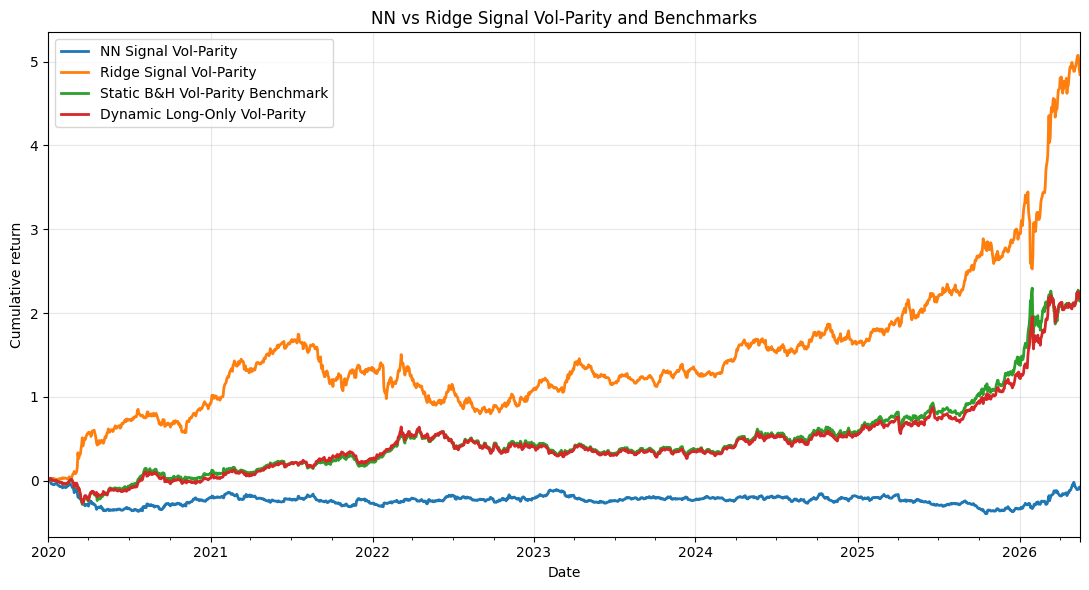

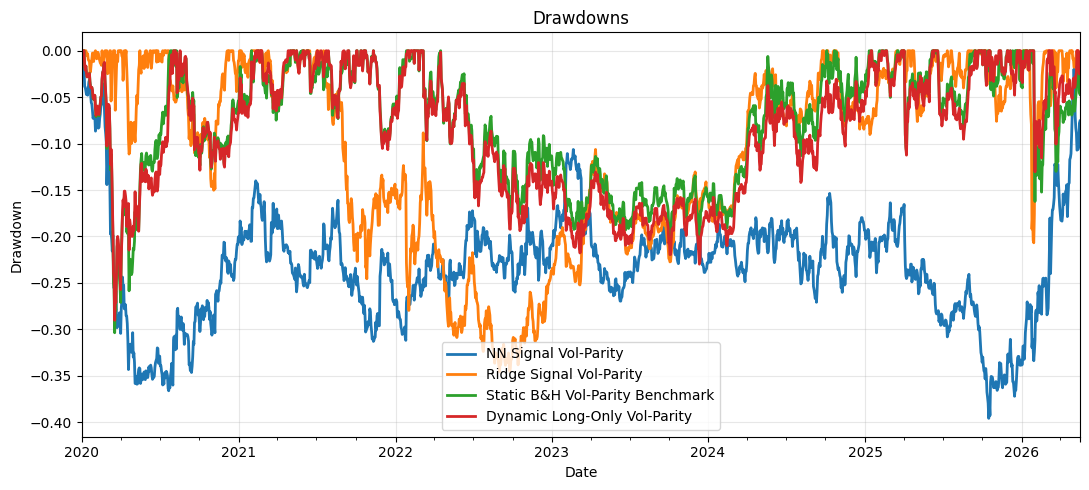


NN signal strategy total return contribution by commodity:
Silver          13.13%
Brent_Crude      2.67%
Natural_Gas      0.95%
Gold           -10.21%
Name: Total Return Contribution, dtype: str

Ridge signal strategy total return contribution by commodity:
Brent_Crude     91.98%
Gold            73.84%
Silver          49.72%
Natural_Gas    -22.84%
Name: Total Return Contribution, dtype: str


In [27]:
"""
Task 3 portfolio backtest for NN and Ridge signal strategies.

Paste this as the next Jupyter notebook code block after both signal-generation blocks:
    1. tasks/task_3/outputs/mlp/nn_test_signals_wide.csv
    2. tasks/task_3/outputs/ridge/ridge_test_signals_wide.csv

What this block does
--------------------
1. Loads daily commodity excess returns for Gold, Silver, Brent Crude and Natural Gas.
2. Loads any available test-window NN and Ridge model signals.
3. Calculates trailing 60-day annualised volatility using only past data.
4. Builds daily inverse-volatility / volatility-parity weights.
5. Constructs these portfolios:
   A. NN signal vol-parity portfolio.
   B. Ridge signal vol-parity portfolio.
   C. Static buy-and-hold vol-parity benchmark.
   D. Dynamic long-only vol-parity benchmark.
6. Saves daily returns, cumulative returns, weights, signals and performance statistics.

Notes
-----
- The model signal files should contain columns: Gold, Silver, Brent_Crude, Natural_Gas.
- The strategy uses signal strength, not just signal sign, through weight = vol-parity weight * signal.
- Transaction costs are zero by default, but can be switched on through TRANSACTION_COST_BPS.
"""

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root() -> Path:
    """Find the repository root whether the notebook runs from root or tasks/task_3."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "source").exists() and (base / "tasks" / "task_3").exists():
            return base
    return Path.cwd()


PROJECT_ROOT = find_project_root()
TASK3_OUTPUT_BASE = PROJECT_ROOT / "tasks" / "task_3" / "outputs"

# =============================================================================
# User-editable settings
# =============================================================================
COMMODITIES_FILE = Path("source/Commodities Data thru 18May26.xlsx")
ASSETS_FILE = Path("data/raw/assets.csv")
COMMODITY_RETURNS_SHEET = "Returns"
OUTPUT_DIR = TASK3_OUTPUT_BASE / "portfolio"

# Model signal files. Each model can have a list of fallback paths.
MODEL_SIGNAL_FILES = {
    "NN": [
        TASK3_OUTPUT_BASE / "mlp" / "nn_test_signals_wide.csv",
    ],
    "Ridge": [
        TASK3_OUTPUT_BASE / "ridge" / "ridge_test_signals_wide.csv",
    ],
}

DATE_COL_CANDIDATES = ["Date", "Dates"]
TEST_START = pd.Timestamp("2020-01-01")
TRADING_DAYS = 252
VOL_LOOKBACK = 60
VOL_FLOOR = 0.05               # 5% annualised floor prevents extreme weights
MAX_ABS_ASSET_WEIGHT = 0.50    # cap individual exposure after signal scaling
GROSS_EXPOSURE_TARGET = 1.00   # 1.00 = fully invested gross exposure before any vol targeting
PORTFOLIO_VOL_TARGET = None    # Example: 0.12 for 12% annualised portfolio vol target; None = no leverage overlay
PORTFOLIO_VOL_LOOKBACK = 60
TRANSACTION_COST_BPS = 0.0     # bps charged per 100% one-way turnover
EXECUTION_LAG_DAYS = 0         # 0 is OK if model features were already lagged; set 1 for extra conservative execution

SELECTED_COMMODITIES = {
    "Gold": "GOLD 100 OZ",
    "Silver": "SILVER",
    "Brent_Crude": "BRENT CRUDE",
    "Natural_Gas": "NATURAL GAS",
}

# =============================================================================
# Data loading helpers
# =============================================================================
def _normalise_text(x: object) -> str:
    return " ".join(str(x).strip().upper().split())


def _find_existing_path(path: Path) -> Path:
    """Find repo inputs whether the notebook is run from root or a subfolder."""
    path = Path(path)
    candidates = [path]
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([base / path, base / path.name])
    candidates.extend([Path("/mnt/data") / path, Path("/mnt/data") / path.name])

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {path}. Tried: {unique_candidates}")


def _find_first_existing_path(paths) -> Path:
    """Return the first existing path from a list of candidate signal files."""
    tried = []
    search_roots = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "tasks" / "task_3"]

    for path in paths:
        path = Path(path)
        candidates = [path]
        for root in search_roots:
            candidates.extend([root / path, root / path.name])
        candidates.extend([Path("/mnt/data") / path, Path("/mnt/data") / path.name])

        seen = set()
        for candidate in candidates:
            key = str(candidate)
            if key in seen:
                continue
            seen.add(key)
            tried.append(candidate)
            if candidate.exists():
                return candidate

    tried_text = "\n".join(f"  - {candidate}" for candidate in tried)
    raise FileNotFoundError(
        "Could not find any Task 3 model signal file. Run the NN and Ridge signal "
        "generation cells first, or check tasks/task_3/outputs/mlp and "
        "tasks/task_3/outputs/ridge. Tried:\n"
        f"{tried_text}"
    )

def _match_return_columns_to_assets(return_columns, assets: pd.DataFrame) -> dict:
    colname_map = dict(zip(assets["ColName"].map(_normalise_text), assets["Commodity"]))
    asset_names = [str(a).strip() for a in assets["Commodity"]]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(_normalise_text(s)), reverse=True)
    mapping = {}

    for raw_col in return_columns:
        raw_norm = _normalise_text(raw_col)
        match = colname_map.get(raw_norm)
        if match is None:
            for asset in asset_names_sorted:
                if raw_norm.startswith(_normalise_text(asset)):
                    match = asset
                    break
        if match is None:
            raise ValueError(f"Could not match source commodity column to data/raw/assets.csv: {raw_col}")
        mapping[raw_col] = match

    return mapping


def _read_date_indexed_csv(path: Path) -> pd.DataFrame:
    """Read a CSV whose first column or named date column is the date index."""
    raw = pd.read_csv(path)
    date_col = None
    for candidate in DATE_COL_CANDIDATES:
        if candidate in raw.columns:
            date_col = candidate
            break
    if date_col is None:
        date_col = raw.columns[0]

    raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
    raw = raw.dropna(subset=[date_col])
    raw = raw.set_index(date_col).sort_index()
    raw.index.name = "Date"
    raw = raw.apply(pd.to_numeric, errors="coerce")
    return raw.replace([np.inf, -np.inf], np.nan)


def load_asset_metadata(assets_file: Path = ASSETS_FILE) -> pd.DataFrame:
    assets_file = _find_existing_path(assets_file)
    assets = pd.read_csv(assets_file)
    required = {"Commodity", "Sector", "ColName"}
    missing = required - set(assets.columns)
    if missing:
        raise ValueError(f"assets.csv is missing columns: {sorted(missing)}")
    assets = assets.copy()
    for col in ["Commodity", "Sector", "ColName"]:
        assets[col] = assets[col].astype(str).str.strip()
    return assets


def load_commodity_returns() -> pd.DataFrame:
    """Load daily simple commodity returns from the current source workbook."""
    workbook_path = _find_existing_path(COMMODITIES_FILE)
    assets = load_asset_metadata()
    raw_returns = pd.read_excel(workbook_path, sheet_name=COMMODITY_RETURNS_SHEET)

    date_col = "Dates" if "Dates" in raw_returns.columns else raw_returns.columns[0]
    raw_returns[date_col] = pd.to_datetime(raw_returns[date_col], errors="coerce")
    raw_returns = raw_returns.dropna(subset=[date_col]).sort_values(date_col)
    raw_returns = raw_returns.drop_duplicates(subset=[date_col], keep="last")
    raw_returns = raw_returns.set_index(date_col)
    raw_returns = raw_returns.apply(pd.to_numeric, errors="coerce")

    col_map = _match_return_columns_to_assets(raw_returns.columns, assets)
    returns = raw_returns.rename(columns=col_map)
    returns = returns[assets["Commodity"].tolist()]
    returns = returns.replace([np.inf, -np.inf], np.nan)
    returns.index.name = "Date"
    return returns


def load_model_signals(model_signal_files: dict[str, list[Path]]) -> dict[str, pd.DataFrame]:
    """Load available model signal files and skip models whose outputs are absent."""
    signals_by_model = {}
    required_cols = list(SELECTED_COMMODITIES.keys())
    missing_models = []

    for model_name, paths in model_signal_files.items():
        try:
            signal_path = _find_first_existing_path(paths)
        except FileNotFoundError:
            missing_models.append(model_name)
            print(f"Skipping {model_name}: signal file not found. If this is Ridge, run the commodity Ridge block in Task3_Ridge.ipynb, not the legacy FX block.")
            continue

        signals = _read_date_indexed_csv(signal_path)
        missing_cols = [c for c in required_cols if c not in signals.columns]
        if missing_cols:
            raise ValueError(
                f"{model_name} signal file is missing columns {missing_cols}. "
                f"Found columns: {signals.columns.tolist()}"
            )
        signals = signals[required_cols].replace([np.inf, -np.inf], np.nan).clip(-1.0, 1.0)
        signals_by_model[model_name] = signals
        print(f"Loaded {model_name} signals from: {signal_path}")

    if not signals_by_model:
        raise FileNotFoundError(
            "No Task 3 model signal files were found. Run the MLP/Ridge generation "
            "cells first so tasks/task_3/outputs/mlp or tasks/task_3/outputs/ridge exists."
        )
    if missing_models:
        print("Missing model outputs skipped:", ", ".join(missing_models))

    return signals_by_model

# =============================================================================
# Portfolio construction helpers
# =============================================================================
def calc_trailing_ann_vol(returns: pd.DataFrame, lookback: int = VOL_LOOKBACK) -> pd.DataFrame:
    """Annualised trailing volatility, shifted so today's return is not used for today's weight."""
    vol = returns.rolling(lookback, min_periods=lookback // 2).std() * np.sqrt(TRADING_DAYS)
    return vol.shift(1).clip(lower=VOL_FLOOR)


def inverse_vol_weights(vol: pd.DataFrame) -> pd.DataFrame:
    """Long-only vol-parity weights. Each row sums to 1 when enough vol data exists."""
    inv_vol = 1.0 / vol
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    return weights.replace([np.inf, -np.inf], np.nan)


def cap_and_rescale_gross(weights: pd.DataFrame, max_abs_weight: float, gross_target: float) -> pd.DataFrame:
    """
    Cap absolute asset weights, then rescale so gross exposure equals gross_target.
    Keeps sign information from the model signal.
    """
    capped = weights.clip(lower=-max_abs_weight, upper=max_abs_weight)
    gross = capped.abs().sum(axis=1)
    scaled = capped.div(gross.replace(0.0, np.nan), axis=0) * gross_target
    return scaled.fillna(0.0)


def apply_portfolio_vol_target(
    base_weights: pd.DataFrame,
    strategy_returns_pre_target: pd.Series,
    target_vol: float | None = PORTFOLIO_VOL_TARGET,
    lookback: int = PORTFOLIO_VOL_LOOKBACK,
) -> pd.DataFrame:
    """Optional portfolio-level volatility targeting."""
    if target_vol is None:
        return base_weights

    realised_vol = strategy_returns_pre_target.rolling(lookback, min_periods=lookback // 2).std() * np.sqrt(TRADING_DAYS)
    leverage = (target_vol / realised_vol.shift(1)).clip(lower=0.0, upper=3.0)
    return base_weights.mul(leverage, axis=0).fillna(0.0)


def calc_turnover(weights: pd.DataFrame) -> pd.Series:
    """One-way turnover, defined as sum(abs(delta weights))."""
    return weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))


def calc_portfolio_returns(weights: pd.DataFrame, returns: pd.DataFrame, tc_bps: float = TRANSACTION_COST_BPS) -> tuple[pd.Series, pd.Series]:
    """Daily portfolio return = sum_i weight_i,t * return_i,t minus optional turnover costs."""
    aligned_weights, aligned_returns = weights.align(returns, join="inner", axis=0)
    gross_returns = (aligned_weights * aligned_returns).sum(axis=1)
    turnover = calc_turnover(aligned_weights)
    costs = turnover * (tc_bps / 10000.0)
    net_returns = gross_returns - costs
    return net_returns.rename("Return"), turnover.rename("Turnover")


def performance_stats(r: pd.Series, turnover: pd.Series | None = None) -> pd.Series:
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    cumulative = (1.0 + r).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1.0

    ann_return = cumulative.iloc[-1] ** (TRADING_DAYS / len(r)) - 1.0
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    hit_rate = (r > 0).mean()

    out = pd.Series({
        "Ann Return": ann_return,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Total Return": cumulative.iloc[-1] - 1.0,
        "Hit Rate": hit_rate,
        "Skew": r.skew(),
        "Avg Daily Return": r.mean(),
        "Worst Day": r.min(),
        "Best Day": r.max(),
    })

    if turnover is not None:
        turnover = turnover.reindex(r.index).dropna()
        out["Avg Daily Turnover"] = turnover.mean()
        out["Annualised Turnover"] = turnover.mean() * TRADING_DAYS

    return out


def build_signal_strategy(
    model_name: str,
    signals: pd.DataFrame,
    base_vp_weights: pd.DataFrame,
    returns_4: pd.DataFrame,
    common_index: pd.Index,
) -> tuple[pd.Series, pd.Series, pd.DataFrame, pd.DataFrame]:
    """Build one signal-driven vol-parity strategy for a model."""
    model_signals = signals.reindex(common_index).shift(EXECUTION_LAG_DAYS)
    raw_signal_weights = base_vp_weights * model_signals
    weights_pre_target = cap_and_rescale_gross(
        raw_signal_weights,
        max_abs_weight=MAX_ABS_ASSET_WEIGHT,
        gross_target=GROSS_EXPOSURE_TARGET,
    )

    returns_pre_target, _ = calc_portfolio_returns(weights_pre_target, returns_4, tc_bps=0.0)
    weights = apply_portfolio_vol_target(weights_pre_target, returns_pre_target)
    strategy_returns, strategy_turnover = calc_portfolio_returns(weights, returns_4, tc_bps=TRANSACTION_COST_BPS)

    strategy_returns.name = f"{model_name} Signal Vol-Parity"
    strategy_turnover.name = f"{model_name} Signal Vol-Parity"
    return strategy_returns, strategy_turnover, weights, model_signals

# =============================================================================
# Run portfolio backtest
# =============================================================================
returns_all = load_commodity_returns()
signals_by_model = load_model_signals(MODEL_SIGNAL_FILES)

# Map clean signal labels to the commodity names in the returns DataFrame.
asset_name_map = {label: commodity for label, commodity in SELECTED_COMMODITIES.items()}
required_return_cols = [asset_name_map[label] for label in SELECTED_COMMODITIES.keys()]
missing_return_cols = [c for c in required_return_cols if c not in returns_all.columns]
if missing_return_cols:
    raise ValueError(f"Missing return columns: {missing_return_cols}")

returns_4 = returns_all[required_return_cols].copy()
returns_4.columns = list(SELECTED_COMMODITIES.keys())
returns_4 = returns_4.loc[returns_4.index >= TEST_START]

# Use the intersection of return dates and all model signal dates for a fair comparison.
common_index = returns_4.index
for model_signals in signals_by_model.values():
    common_index = common_index.intersection(model_signals.loc[model_signals.index >= TEST_START].index)
common_index = common_index.sort_values()

returns_4 = returns_4.loc[common_index]
if len(returns_4) == 0:
    raise ValueError("No overlapping dates between commodity returns and model signal files.")

# Vol-parity base weights from trailing realised vol.
trailing_vol = calc_trailing_ann_vol(returns_all[required_return_cols])
trailing_vol.columns = list(SELECTED_COMMODITIES.keys())
trailing_vol = trailing_vol.reindex(common_index)
base_vp_weights = inverse_vol_weights(trailing_vol).fillna(0.0)

# A and B. Signal strategies for each model.
model_returns = []
model_turnovers = []
model_weights = {}
model_signals_aligned = {}

for model_name, signals in signals_by_model.items():
    strategy_returns, strategy_turnover, weights, tradable_signals = build_signal_strategy(
        model_name=model_name,
        signals=signals,
        base_vp_weights=base_vp_weights,
        returns_4=returns_4,
        common_index=common_index,
    )
    model_returns.append(strategy_returns)
    model_turnovers.append(strategy_turnover)
    model_weights[f"{model_name}_Signal_Weights"] = weights
    model_signals_aligned[f"{model_name}_Signals"] = tradable_signals

# C. Static buy-and-hold benchmark: use the first available vol-parity weights and hold them fixed.
valid_weight_mask = base_vp_weights.abs().sum(axis=1) > 0
if not valid_weight_mask.any():
    raise ValueError("No valid vol-parity weights were available. Check return data and vol lookback.")

first_valid_weight_date = base_vp_weights.index[valid_weight_mask][0]
initial_vp_weights = base_vp_weights.loc[first_valid_weight_date]
static_bh_weights = pd.DataFrame(
    np.tile(initial_vp_weights.values, (len(base_vp_weights), 1)),
    index=base_vp_weights.index,
    columns=base_vp_weights.columns,
)
static_bh_weights = cap_and_rescale_gross(
    static_bh_weights,
    max_abs_weight=MAX_ABS_ASSET_WEIGHT,
    gross_target=GROSS_EXPOSURE_TARGET,
)
static_bh_returns, static_bh_turnover = calc_portfolio_returns(static_bh_weights, returns_4, tc_bps=TRANSACTION_COST_BPS)
static_bh_returns.name = "Static B&H Vol-Parity Benchmark"
static_bh_turnover.name = "Static B&H Vol-Parity Benchmark"

# D. Dynamic long-only benchmark: same daily vol-parity risk weights, always long.
dyn_bh_weights_pre_target = cap_and_rescale_gross(
    base_vp_weights,
    max_abs_weight=MAX_ABS_ASSET_WEIGHT,
    gross_target=GROSS_EXPOSURE_TARGET,
)
dyn_bh_returns_pre_target, _ = calc_portfolio_returns(dyn_bh_weights_pre_target, returns_4, tc_bps=0.0)
dyn_bh_weights = apply_portfolio_vol_target(dyn_bh_weights_pre_target, dyn_bh_returns_pre_target)
dyn_bh_returns, dyn_bh_turnover = calc_portfolio_returns(dyn_bh_weights, returns_4, tc_bps=TRANSACTION_COST_BPS)
dyn_bh_returns.name = "Dynamic Long-Only Vol-Parity"
dyn_bh_turnover.name = "Dynamic Long-Only Vol-Parity"

# Combine outputs.
portfolio_returns = pd.concat(
    model_returns + [static_bh_returns, dyn_bh_returns],
    axis=1,
).dropna()

turnover = pd.concat(
    model_turnovers + [static_bh_turnover, dyn_bh_turnover],
    axis=1,
).reindex(portfolio_returns.index)

cumulative_returns = (1.0 + portfolio_returns).cumprod() - 1.0
weights_out = pd.concat(
    {
        **{k: v.reindex(portfolio_returns.index) for k, v in model_weights.items()},
        "Static_Buy_Hold_Vol_Parity_Weights": static_bh_weights.reindex(portfolio_returns.index),
        "Dynamic_Long_Only_Vol_Parity_Weights": dyn_bh_weights.reindex(portfolio_returns.index),
        **{k: v.reindex(portfolio_returns.index) for k, v in model_signals_aligned.items()},
        "Trailing_Ann_Vol": trailing_vol.reindex(portfolio_returns.index),
    },
    axis=1,
)

stats = pd.DataFrame({
    col: performance_stats(portfolio_returns[col], turnover[col])
    for col in portfolio_returns.columns
}).T

# Relative comparisons against the static buy-and-hold benchmark.
relative_stats_rows = []
for col in portfolio_returns.columns:
    if "Signal Vol-Parity" in col:
        relative_return = portfolio_returns[col] - portfolio_returns["Static B&H Vol-Parity Benchmark"]
        relative_stats_rows.append(
            performance_stats(relative_return).rename(f"{col} minus Static B&H")
        )
if relative_stats_rows:
    stats = pd.concat([stats, pd.DataFrame(relative_stats_rows)], axis=0)

print("\nTask 3 portfolio comparison, test window")
print(f"Date range: {portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")
print(f"Transaction cost assumption: {TRANSACTION_COST_BPS:.2f} bps per 100% one-way turnover")
print("\nPerformance statistics:")
display_cols = ["Ann Return", "Ann Vol", "Sharpe", "Max Drawdown", "Calmar", "Total Return", "Hit Rate", "Avg Daily Turnover"]
stats_display = stats[display_cols].copy()
stats_display = stats_display.map(lambda x: f"{x:,.2%}" if pd.notna(x) and abs(x) < 10 else f"{x:,.2f}")
print(stats_display)

# Save CSV outputs for report charts/tables.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
portfolio_returns.to_csv(OUTPUT_DIR / "portfolio_returns_test.csv", index_label="Date")
cumulative_returns.to_csv(OUTPUT_DIR / "portfolio_cumulative_returns_test.csv", index_label="Date")
weights_out.to_csv(OUTPUT_DIR / "portfolio_weights_signals_and_vols_test.csv", index_label="Date")
stats.to_csv(OUTPUT_DIR / "portfolio_performance_stats_test.csv", index_label="Strategy")

# Plot cumulative performance.
ax = cumulative_returns.plot(figsize=(11, 6), linewidth=2)
ax.set_title("NN vs Ridge Signal Vol-Parity and Benchmarks")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "portfolio_cumulative_returns_test.png", dpi=150)
plt.show()

# Plot drawdowns.
growth = (1.0 + portfolio_returns).cumprod()
drawdowns = growth / growth.cummax() - 1.0
ax = drawdowns.plot(figsize=(11, 5), linewidth=2)
ax.set_title("Drawdowns")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "portfolio_drawdowns_test.png", dpi=150)
plt.show()

# Contribution tables by commodity for each model strategy.
for model_name, weights in model_weights.items():
    strategy_name = model_name.replace("_Signal_Weights", "")
    asset_contrib = (weights.reindex(portfolio_returns.index) * returns_4.reindex(portfolio_returns.index)).sum(axis=0)
    asset_contrib = asset_contrib.sort_values(ascending=False).rename("Total Return Contribution")
    print(f"\n{strategy_name} signal strategy total return contribution by commodity:")
    print(asset_contrib.apply(lambda x: f"{x:,.2%}"))


For each commodity, we trained a separate small feed-forward neural network to predict the next 21-trading-day excess return scaled by trailing 60-day annualised volatility. The input features combined commodity-specific trend and volatility variables with economically motivated auxiliary variables, including FX, rates, credit spreads, equity indices, implied volatility, macro surprise indices and positioning. All features were lagged by one trading day to avoid using information unavailable at the time of signal formation. The model was trained on the pre-2020 sample, with 2019 used for validation and 2020 onward reserved for out-of-sample testing. The network had two hidden layers with 32 and 16 units, ReLU activations, dropout and weight decay to reduce overfitting. The final prediction was transformed through a tanh function to produce a bounded signal between -1 and +1, which was then used in the portfolio construction step.

Comparison return sample:


,NN Signal Vol-Parity,Ridge Signal Vol-Parity,Static B&H Vol-Parity Benchmark,Dynamic Long-Only Vol-Parity,Full_23_Commodity_Market_Factor,Four_Asset_Equal_Weight_Factor
Date,,,,,,
2020-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-02,-0.000451,-0.005974,0.001330,0.001328,0.000532,-0.004169
2020-01-03,-0.006497,0.009871,0.016329,0.016319,0.000217,0.015293
2020-01-06,-0.003828,0.004508,0.006228,0.006193,0.000775,0.004759
2020-01-07,-0.006935,0.002788,0.003772,0.003816,0.000444,0.004639


Date range:
2020-01-01 00:00:00 to 2026-05-18 00:00:00
Number of observations: 1664


,Ann Return,Ann Vol,Sharpe,Max Drawdown,Calmar,Skew,Total Return,Obs
Strategy,,,,,,,,
NN Signal Vol-Parity,-0.011840,0.209134,-0.056612,-0.395900,-0.029905,0.284581,-0.075632,1664
Ridge Signal Vol-Parity,0.306592,0.220589,1.389882,-0.345808,0.886598,0.250614,4.846467,1664
Static B&H Vol-Parity Benchmark,0.189324,0.215931,0.876782,-0.303733,0.623324,-0.644525,2.142108,1664
Dynamic Long-Only Vol-Parity,0.191769,0.204075,0.939698,-0.290275,0.660645,-0.376305,2.184997,1664
Full_23_Commodity_Market_Factor,0.104245,0.161955,0.643669,-0.423581,0.246105,-2.367383,0.924729,1664
Four_Asset_Equal_Weight_Factor,0.172055,0.264617,0.650204,-0.397103,0.433276,0.080537,1.852829,1664


,NN Signal Vol-Parity,Ridge Signal Vol-Parity,Static B&H Vol-Parity Benchmark,Dynamic Long-Only Vol-Parity,Full_23_Commodity_Market_Factor,Four_Asset_Equal_Weight_Factor
Date,,,,,,
2026-05-12,0.893935,6.067293,3.241592,3.223076,1.970404,2.889316
2026-05-13,0.893947,6.076003,3.273723,3.253386,1.979627,2.915266
2026-05-14,0.896597,6.015149,3.232071,3.227518,1.950061,2.887260
2026-05-15,0.921971,5.891603,3.146701,3.171684,1.919357,2.843059
2026-05-18,0.924368,5.846467,3.142108,3.184997,1.924729,2.852829


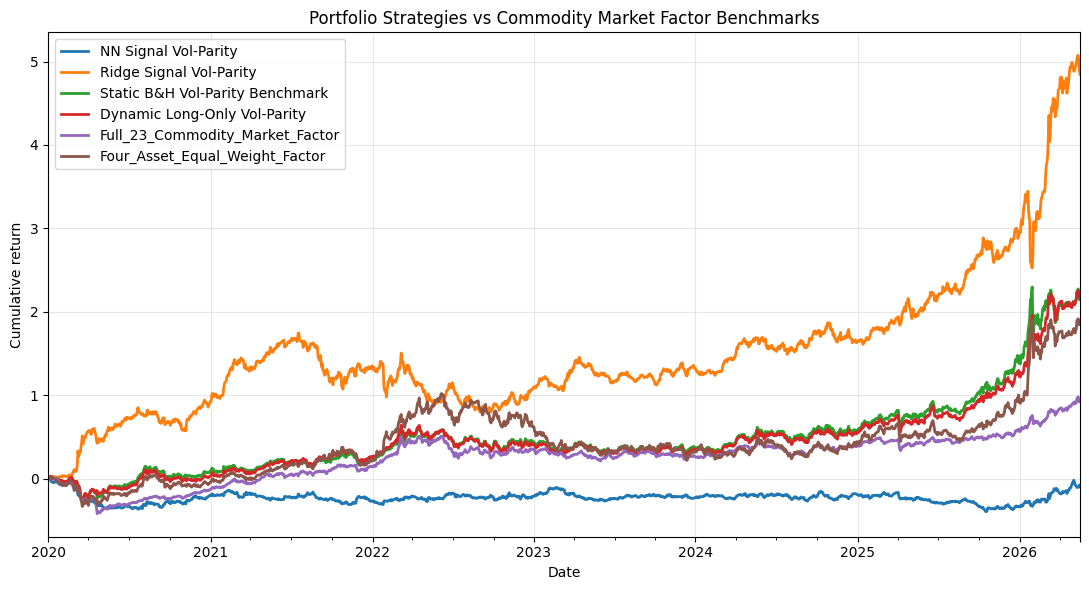

Annualised Alpha  \
Strategy                        Benchmark                                           
NN Signal Vol-Parity            Full 23-Commodity Market Factor          0.007719   
                                Four-Asset Equal-Weight Factor           0.015481   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor          0.272408   
                                Four-Asset Equal-Weight Factor           0.298273   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor          0.087587   
                                Four-Asset Equal-Weight Factor           0.055984   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor          0.094159   
                                Four-Asset Equal-Weight Factor           0.060204   

                                                                 Market Beta  \
Strategy                        Benchmark                                      
NN Signal Vol-Parity            Full 23-Commodity Market Factor     0.019409   
                                Four-Asset Equal-Weight Factor     -0.028792   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor     0.172669   
                                Four-Asset Equal-Weight Factor     -0.033221   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor     0.971400   
                                Four-Asset Equal-Weight Factor      0.727129   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor     0.908442   
                                Four-Asset Equal-Weight Factor      0.702716   

                                                                 R_squared  \
Strategy                        Benchmark                                    
NN Signal Vol-Parity            Full 23-Commodity Market Factor   0.000226   
                                Four-Asset Equal-Weight Factor    0.001327   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor   0.016071   
                                Four-Asset Equal-Weight Factor    0.001588   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor   0.530830   
                                Four-Asset Equal-Weight Factor    0.794016   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor   0.519762   
                                Four-Asset Equal-Weight Factor    0.830264   

                                                                 Alpha t-stat  \
Strategy                        Benchmark                                       
NN Signal Vol-Parity            Full 23-Commodity Market Factor      0.094730   
                                Four-Asset Equal-Weight Factor       0.190090   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor      3.195104   
                                Four-Asset Equal-Weight Factor       3.472642   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor      1.519812   
                                Four-Asset Equal-Weight Factor       1.465950   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor      1.708735   
                                Four-Asset Equal-Weight Factor       1.837508   

                                                                 Beta t-stat  \
Strategy                        Benchmark                                      
NN Signal Vol-Parity            Full 23-Commodity Market Factor     0.612824   
                                Four-Asset Equal-Weight Factor     -1.486176   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor     5.210271   
                                Four-Asset Equal-Weight Factor     -1.625949   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor    43.363905   
                                Four-Asset Equal-Weight Factor     80.041066   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor    42.412083   
                                Four-Asset Equal-Weight Factor     90.164630   

                    

Saved outputs to: /Users/faisal/Desktop/BUSI97075-backtesting/tasks/task_3/outputs/market_factor


In [28]:
# =============================================================================
# Task 3 Market Factor Benchmark Comparison
# Includes NN, Ridge, static buy-and-hold and dynamic long-only portfolios
# Active-return table output removed
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def find_project_root() -> Path:
    """Find the repository root whether the notebook runs from root or tasks/task_3."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "source").exists() and (base / "tasks" / "task_3").exists():
            return base
    return Path.cwd()


PROJECT_ROOT = find_project_root()
TASK3_OUTPUT_BASE = PROJECT_ROOT / "tasks" / "task_3" / "outputs"

TRADING_DAYS = 252

# -----------------------------
# Directory paths
# -----------------------------
portfolio_dir = TASK3_OUTPUT_BASE / "portfolio"
output_dir = TASK3_OUTPUT_BASE / "market_factor"
output_dir.mkdir(exist_ok=True)

COMMODITIES_FILE = Path("source/Commodities Data thru 18May26.xlsx")
ASSETS_FILE = Path("data/raw/assets.csv")
COMMODITY_RETURNS_SHEET = "Returns"

# -----------------------------
# File paths
# -----------------------------
portfolio_returns_path = portfolio_dir / "portfolio_returns_test.csv"
commodity_returns_path = COMMODITIES_FILE
assets_path = ASSETS_FILE

# Fallbacks for notebook folders where inputs are resolved from a subdirectory.
def find_path(primary_path: Path, fallback_name: str) -> Path:
    primary_path = Path(primary_path)
    candidates = [primary_path, Path(fallback_name)]
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([base / primary_path, base / fallback_name])
    candidates.extend([Path("/mnt/data") / primary_path, Path("/mnt/data") / fallback_name])

    seen = set()
    unique_candidates = []
    for p in candidates:
        key = str(p)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {fallback_name}. Tried: {unique_candidates}")


def normalise_text(x: object) -> str:
    return " ".join(str(x).strip().upper().split())


def load_source_commodity_returns(workbook_path: Path, assets_file: Path) -> pd.DataFrame:
    raw = pd.read_excel(workbook_path, sheet_name=COMMODITY_RETURNS_SHEET)
    assets = pd.read_csv(assets_file)
    for col in ["Commodity", "ColName"]:
        assets[col] = assets[col].astype(str).str.strip()

    date_col = "Dates" if "Dates" in raw.columns else raw.columns[0]
    raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
    raw = raw.dropna(subset=[date_col]).sort_values(date_col)
    raw = raw.drop_duplicates(subset=[date_col], keep="last").set_index(date_col)
    raw = raw.apply(pd.to_numeric, errors="coerce")

    colname_map = dict(zip(assets["ColName"].map(normalise_text), assets["Commodity"]))
    commodity_names = assets["Commodity"].tolist()
    commodity_names_sorted = sorted(commodity_names, key=lambda x: len(normalise_text(x)), reverse=True)
    mapping = {}
    for raw_col in raw.columns:
        raw_norm = normalise_text(raw_col)
        match = colname_map.get(raw_norm)
        if match is None:
            for commodity in commodity_names_sorted:
                if raw_norm.startswith(normalise_text(commodity)):
                    match = commodity
                    break
        if match is None:
            raise ValueError(f"Could not match source commodity column: {raw_col}")
        mapping[raw_col] = match

    returns = raw.rename(columns=mapping)
    returns = returns[commodity_names]
    returns.index.name = "Date"
    return returns.replace([np.inf, -np.inf], np.nan)

portfolio_returns_path = find_path(portfolio_returns_path, "portfolio_returns_test.csv")
commodity_returns_path = find_path(commodity_returns_path, "Commodities Data thru 18May26.xlsx")
assets_path = find_path(assets_path, "assets.csv")

# -----------------------------
# Load data
# -----------------------------
strategy_returns = pd.read_csv(
    portfolio_returns_path,
    index_col=0,
    parse_dates=True,
)

commodity_returns = load_source_commodity_returns(commodity_returns_path, assets_path)
market_factor = pd.DataFrame({
    "MKT_EQ_WEIGHT_AVAILABLE": commodity_returns.mean(axis=1, skipna=True)
})

# Clean indices and column names.
for df in [strategy_returns, commodity_returns, market_factor]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    df.columns = df.columns.astype(str).str.strip()

# -----------------------------
# Build market factor benchmarks
# -----------------------------
full_market = market_factor["MKT_EQ_WEIGHT_AVAILABLE"].rename(
    "Full_23_Commodity_Market_Factor"
)

four_asset_cols = [
    "GOLD 100 OZ",
    "SILVER",
    "BRENT CRUDE",
    "NATURAL GAS",
]

missing_cols = [c for c in four_asset_cols if c not in commodity_returns.columns]
if missing_cols:
    raise ValueError(f"Missing four-asset columns in commodity_returns: {missing_cols}")

four_asset_factor = (
    commodity_returns[four_asset_cols]
    .mean(axis=1, skipna=True)
    .rename("Four_Asset_Equal_Weight_Factor")
)

# -----------------------------
# Align all benchmark returns to the portfolio return dates
# -----------------------------
comparison_returns = pd.concat(
    [
        strategy_returns,
        full_market.reindex(strategy_returns.index),
        four_asset_factor.reindex(strategy_returns.index),
    ],
    axis=1,
).dropna()

if comparison_returns.empty:
    raise ValueError(
        "comparison_returns is empty after alignment. Check date overlap and column names."
    )

print("Comparison return sample:")
display(comparison_returns.head())

print("Date range:")
print(comparison_returns.index.min(), "to", comparison_returns.index.max())
print("Number of observations:", len(comparison_returns))

# -----------------------------
# Performance statistics
# -----------------------------
def performance_stats(returns, trading_days=252):
    stats = []

    for col in returns.columns:
        r = pd.to_numeric(returns[col], errors="coerce").dropna()

        if len(r) == 0:
            print(f"Skipping {col}: no valid observations")
            continue

        cumulative = (1.0 + r).cumprod()
        drawdown = cumulative / cumulative.cummax() - 1.0

        ann_return = cumulative.iloc[-1] ** (trading_days / len(r)) - 1.0
        ann_vol = r.std() * np.sqrt(trading_days)
        sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
        max_dd = drawdown.min()
        calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
        total_return = cumulative.iloc[-1] - 1.0

        stats.append({
            "Strategy": col,
            "Ann Return": ann_return,
            "Ann Vol": ann_vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Calmar": calmar,
            "Skew": r.skew(),
            "Total Return": total_return,
            "Obs": len(r),
        })

    if len(stats) == 0:
        raise ValueError("No valid return series were available for performance_stats().")

    return pd.DataFrame(stats).set_index("Strategy")

stats_table = performance_stats(comparison_returns)
display(stats_table)

# -----------------------------
# Cumulative performance
# -----------------------------
cumulative_returns = (1.0 + comparison_returns).cumprod()
display(cumulative_returns.tail())

ax = (cumulative_returns - 1.0).plot(figsize=(11, 6), linewidth=2)
ax.set_title("Portfolio Strategies vs Commodity Market Factor Benchmarks")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "strategy_vs_market_factor_cumulative_returns.png", dpi=150)
plt.show()

# -----------------------------
# Market factor regression
# -----------------------------
def market_factor_regression(strategy_ret, market_ret, trading_days=252):
    df = pd.concat([strategy_ret, market_ret], axis=1).dropna()
    df.columns = ["strategy", "market"]

    if len(df) < 30:
        return {
            "Annualised Alpha": np.nan,
            "Market Beta": np.nan,
            "R_squared": np.nan,
            "Alpha t-stat": np.nan,
            "Beta t-stat": np.nan,
            "Obs": len(df),
        }

    y = df["strategy"].to_numpy(dtype=float)
    x = df["market"].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(x)), x])
    beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta_hat
    resid = y - fitted

    dof = len(y) - X.shape[1]
    sigma2 = np.sum(resid ** 2) / dof if dof > 0 else np.nan
    xtx_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(sigma2 * xtx_inv)) if np.isfinite(sigma2) else np.array([np.nan, np.nan])
    tstats = beta_hat / se

    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum(resid ** 2)
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "Annualised Alpha": beta_hat[0] * trading_days,
        "Market Beta": beta_hat[1],
        "R_squared": r_squared,
        "Alpha t-stat": tstats[0],
        "Beta t-stat": tstats[1],
        "Obs": int(len(y)),
    }

regression_rows = []
strategy_cols = list(strategy_returns.columns)

for strategy_col in strategy_cols:
    reg_full = market_factor_regression(
        comparison_returns[strategy_col],
        comparison_returns["Full_23_Commodity_Market_Factor"],
    )
    reg_full["Strategy"] = strategy_col
    reg_full["Benchmark"] = "Full 23-Commodity Market Factor"
    regression_rows.append(reg_full)

    reg_four = market_factor_regression(
        comparison_returns[strategy_col],
        comparison_returns["Four_Asset_Equal_Weight_Factor"],
    )
    reg_four["Strategy"] = strategy_col
    reg_four["Benchmark"] = "Four-Asset Equal-Weight Factor"
    regression_rows.append(reg_four)

regression_table = pd.DataFrame(regression_rows).set_index(["Strategy", "Benchmark"])
display(regression_table)

# -----------------------------
# Save outputs
# -----------------------------
comparison_returns.to_csv(output_dir / "strategy_vs_market_factor_returns.csv")
cumulative_returns.to_csv(output_dir / "strategy_vs_market_factor_cumulative_returns.csv")
stats_table.to_csv(output_dir / "strategy_vs_market_factor_stats.csv")
regression_table.to_csv(output_dir / "strategy_market_factor_regressions.csv")

print(f"Saved outputs to: {output_dir.resolve()}")
